# TaxGPT — Episode 11: The Training Loop

Companion notebook to blog post *"Training an LLM From Scratch: Loss, Optimizer, and the Training Loop (Episode 11)"*.

> **This notebook trains on synthetic toy data, not TaxGPT's real GST corpus.** The point is to make cross-entropy loss, AdamW, the warmup+cosine LR schedule, and gradient clipping mechanically concrete -- and to prove the training loop actually drives loss down, end to end. It is NOT a substitute for your real training run's numbers (batch size, step count, hardware, actual loss curve) -- those still need to come from you, same caveat as the blog post.

Reference: Sebastian Raschka, *Build a Large Language Model (From Scratch)*, Ch. 5; Andrej Karpathy, *Let's Reproduce GPT-2 (124M)*, Section 3.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import matplotlib.pyplot as plt

torch.manual_seed(0)

## 1. Cross-entropy loss: predicted distribution vs. the actual next token

In [2]:
vocab_size = 12
logits = torch.randn(1, 5, vocab_size)          # (batch, seq_len, vocab) -- untrained, random
targets = torch.randint(0, vocab_size, (1, 5))    # the actual next tokens

loss = F.cross_entropy(logits.view(-1, vocab_size), targets.view(-1))
print("logits shape: ", logits.shape)
print("targets shape:", targets.shape)
print("loss:", loss.item())

# sanity check from Episode 10's notebook: a freshly initialized model should have
# loss close to -ln(1/vocab_size) -- i.e. as bad as guessing uniformly at random
expected_random_loss = -math.log(1 / vocab_size)
print(f"expected loss at random init: {expected_random_loss:.4f}")

logits shape:  torch.Size([1, 5, 12])
targets shape: torch.Size([1, 5])
loss: 3.0094962120056152
expected loss at random init: 2.4849


## 2. Warmup + cosine decay: the learning rate schedule, plotted

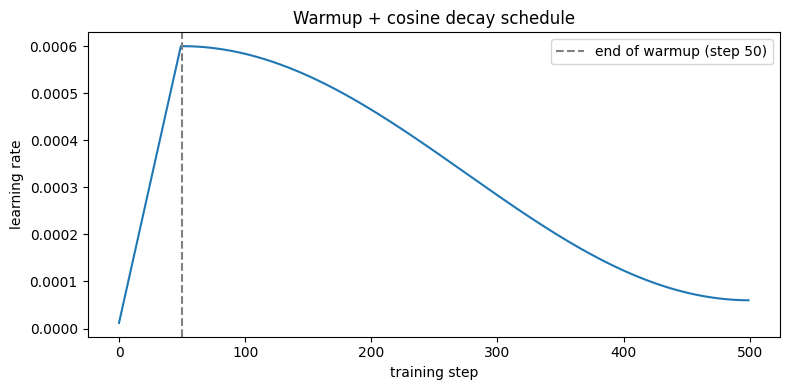

lr at step 0:   1.20e-05
lr at step 50 (peak): 6.00e-04
lr at step 499 (end):  6.00e-05


In [3]:
def get_lr(step, warmup_steps, max_steps, max_lr, min_lr):
    if step < warmup_steps:
        return max_lr * (step + 1) / warmup_steps
    if step > max_steps:
        return min_lr
    decay_ratio = (step - warmup_steps) / (max_steps - warmup_steps)
    coeff = 0.5 * (1.0 + math.cos(math.pi * decay_ratio))
    return min_lr + coeff * (max_lr - min_lr)

warmup_steps, max_steps = 50, 500
max_lr, min_lr = 6e-4, 6e-5

steps = list(range(max_steps))
lrs = [get_lr(s, warmup_steps, max_steps, max_lr, min_lr) for s in steps]

plt.figure(figsize=(8, 4))
plt.plot(steps, lrs)
plt.axvline(warmup_steps, color='gray', linestyle='--', label=f'end of warmup (step {warmup_steps})')
plt.xlabel("training step")
plt.ylabel("learning rate")
plt.title("Warmup + cosine decay schedule")
plt.legend()
plt.tight_layout()
plt.show()

print(f"lr at step 0:   {lrs[0]:.2e}")
print(f"lr at step {warmup_steps} (peak): {lrs[warmup_steps]:.2e}")
print(f"lr at step {max_steps-1} (end):  {lrs[-1]:.2e}")

## 3. Gradient clipping: capping the damage from one bad batch

In [4]:
torch.manual_seed(1)
toy_model = nn.Linear(16, 16)

# simulate a batch that produces an unusually large gradient
x = torch.randn(4, 16) * 50   # deliberately large-magnitude input
out = toy_model(x)
loss = out.pow(2).sum()
loss.backward()

grad_norm_before = torch.sqrt(sum((p.grad ** 2).sum() for p in toy_model.parameters())).item()
print(f"gradient norm BEFORE clipping: {grad_norm_before:.2f}")

torch.nn.utils.clip_grad_norm_(toy_model.parameters(), max_norm=1.0)

grad_norm_after = torch.sqrt(sum((p.grad ** 2).sum() for p in toy_model.parameters())).item()
print(f"gradient norm AFTER clipping:  {grad_norm_after:.2f}")
print(f"(should be capped at ~1.0)")

gradient norm BEFORE clipping: 96183.73
gradient norm AFTER clipping:  1.00
(should be capped at ~1.0)


## 4. A real training loop, on synthetic toy data

This is the part worth actually running rather than just reading: a tiny decoder-only model (from Episode 10's `TaxGPT` class, shrunk down), trained on a repeating synthetic token pattern, for long enough to watch the loss actually go down. Not GST law -- but a real, executed proof that the loop in the blog post works end to end, not just pseudocode.

**A note on initialization, caught by checking the numbers rather than assuming them:** PyTorch's default weight initialization for `nn.Linear` and `nn.Embedding` isn't tuned for this use case -- run a freshly initialized model here and its starting loss can land well above the "uniform random guess" baseline (`-ln(1/vocab_size)`), because the model starts out confidently wrong rather than genuinely uncertain. Karpathy's *Let's Reproduce GPT-2* video addresses this directly (its Section 1 covers "model initialization: std 0.02") -- the cells below show the mismatch with default init, then fix it the same way, and confirm the fix actually closes the gap before training starts.

In [5]:
class LayerNorm(nn.Module):
    def __init__(self, emb_dim, eps=1e-5):
        super().__init__()
        self.eps = eps
        self.gamma = nn.Parameter(torch.ones(emb_dim))
        self.beta = nn.Parameter(torch.zeros(emb_dim))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        return self.gamma * (x - mean) / torch.sqrt(var + self.eps) + self.beta


class MultiHeadAttention(nn.Module):
    def __init__(self, emb_dim, n_heads, context_len):
        super().__init__()
        self.n_heads = n_heads
        self.head_dim = emb_dim // n_heads
        self.W_q = nn.Linear(emb_dim, emb_dim, bias=False)
        self.W_k = nn.Linear(emb_dim, emb_dim, bias=False)
        self.W_v = nn.Linear(emb_dim, emb_dim, bias=False)
        self.out_proj = nn.Linear(emb_dim, emb_dim)
        self.register_buffer("mask", torch.tril(torch.ones(context_len, context_len)))

    def forward(self, x):
        B, T, C = x.shape
        Q = self.W_q(x).view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        K = self.W_k(x).view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        V = self.W_v(x).view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        scores = (Q @ K.transpose(-2, -1)) / math.sqrt(self.head_dim)
        scores = scores.masked_fill(self.mask[:T, :T] == 0, float('-inf'))
        attn = F.softmax(scores, dim=-1)
        out = (attn @ V).transpose(1, 2).contiguous().view(B, T, C)
        return self.out_proj(out)


class FeedForward(nn.Module):
    def __init__(self, emb_dim, hidden_dim):
        super().__init__()
        self.fc1 = nn.Linear(emb_dim, hidden_dim)
        self.gelu = nn.GELU()
        self.fc2 = nn.Linear(hidden_dim, emb_dim)

    def forward(self, x):
        return self.fc2(self.gelu(self.fc1(x)))


class TransformerBlock(nn.Module):
    def __init__(self, emb_dim, n_heads, hidden_dim, context_len):
        super().__init__()
        self.norm1 = LayerNorm(emb_dim)
        self.attn = MultiHeadAttention(emb_dim, n_heads, context_len)
        self.norm2 = LayerNorm(emb_dim)
        self.ff = FeedForward(emb_dim, hidden_dim)

    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        x = x + self.ff(self.norm2(x))
        return x


class TinyGPT(nn.Module):
    """Same architecture family as TaxGPT (Episode 10), scaled down for a fast toy training run."""
    def __init__(self, vocab_size, emb_dim, n_heads, n_layers, hidden_dim, context_len):
        super().__init__()
        self.token_embedding = nn.Embedding(vocab_size, emb_dim)
        self.positional_embedding = nn.Embedding(context_len, emb_dim)
        self.blocks = nn.Sequential(*[
            TransformerBlock(emb_dim, n_heads, hidden_dim, context_len) for _ in range(n_layers)
        ])
        self.final_norm = LayerNorm(emb_dim)
        self.output_head = nn.Linear(emb_dim, vocab_size, bias=False)
        self.output_head.weight = self.token_embedding.weight  # weight tying, Episode 10

    def forward(self, token_ids):
        B, T = token_ids.shape
        x = self.token_embedding(token_ids) + self.positional_embedding(torch.arange(T))
        x = self.blocks(x)
        x = self.final_norm(x)
        return self.output_head(x)

print("TinyGPT defined -- same architecture family as TaxGPT, scaled down for a fast toy run")

TinyGPT defined -- same architecture family as TaxGPT, scaled down for a fast toy run


In [6]:
# synthetic toy corpus: a simple repeating pattern the model can actually learn to predict
# (a real corpus needs Episode 2's tokenizer -- this is purely for a fast, demonstrable training loop)
torch.manual_seed(2)
TOY_VOCAB = 16
pattern = torch.tensor([1, 2, 3, 4, 5, 1, 2, 3, 4, 5] * 200)  # a learnable repeating sequence

CONTEXT_LEN = 8
def get_batch(batch_size=16):
    ix = torch.randint(0, len(pattern) - CONTEXT_LEN - 1, (batch_size,))
    x = torch.stack([pattern[i:i+CONTEXT_LEN] for i in ix])
    y = torch.stack([pattern[i+1:i+CONTEXT_LEN+1] for i in ix])
    return x, y

model = TinyGPT(vocab_size=TOY_VOCAB, emb_dim=32, n_heads=4, n_layers=2, hidden_dim=64, context_len=CONTEXT_LEN)

# check initial loss BEFORE applying GPT-2-style init, to see the actual mismatch
with torch.no_grad():
    x0, y0 = get_batch()
    loss_default_init = F.cross_entropy(model(x0).view(-1, TOY_VOCAB), y0.view(-1)).item()
print(f"loss with PyTorch's DEFAULT init: {loss_default_init:.4f}")
print(f"expected loss if predictions were uniform: {-math.log(1/TOY_VOCAB):.4f}")
print("-> these do NOT match. Default init isn't calibrated to predict near-uniformly at step 0.")
print()

# GPT-2-style init (std=0.02) -- referenced explicitly in Karpathy's "Let's Reproduce GPT-2" video
def gpt2_style_init(module):
    if isinstance(module, nn.Linear):
        nn.init.normal_(module.weight, mean=0.0, std=0.02)
        if module.bias is not None:
            nn.init.zeros_(module.bias)
    elif isinstance(module, nn.Embedding):
        nn.init.normal_(module.weight, mean=0.0, std=0.02)

model.apply(gpt2_style_init)

with torch.no_grad():
    loss_gpt2_init = F.cross_entropy(model(x0).view(-1, TOY_VOCAB), y0.view(-1)).item()
print(f"loss with GPT-2-style init (std=0.02): {loss_gpt2_init:.4f}")
print(f"expected loss if predictions were uniform: {-math.log(1/TOY_VOCAB):.4f}")
print("-> much closer. This is why real GPT-2 training code initializes weights this way --")
print("   it starts the model out genuinely uncertain, rather than confidently wrong.")

optimizer = torch.optim.AdamW(model.parameters(), lr=3e-3, weight_decay=0.01)

MAX_STEPS = 300
WARMUP_STEPS = 20
losses = []

model.train()
for step in range(MAX_STEPS):
    x, y = get_batch()
    optimizer.zero_grad()

    logits = model(x)
    loss = F.cross_entropy(logits.view(-1, TOY_VOCAB), y.view(-1))
    loss.backward()

    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

    lr = get_lr(step, WARMUP_STEPS, MAX_STEPS, max_lr=3e-3, min_lr=3e-4)
    for pg in optimizer.param_groups:
        pg['lr'] = lr

    optimizer.step()
    losses.append(loss.item())

    if step % 50 == 0 or step == MAX_STEPS - 1:
        print(f"step {step:4d} | loss {loss.item():.4f} | lr {lr:.2e}")

loss with PyTorch's DEFAULT init: 18.4678
expected loss if predictions were uniform: 2.7726
-> these do NOT match. Default init isn't calibrated to predict near-uniformly at step 0.

loss with GPT-2-style init (std=0.02): 2.8233
expected loss if predictions were uniform: 2.7726
-> much closer. This is why real GPT-2 training code initializes weights this way --
   it starts the model out genuinely uncertain, rather than confidently wrong.


step    0 | loss 2.8193 | lr 1.50e-04


step   50 | loss 0.0954 | lr 2.92e-03


step  100 | loss 0.0127 | lr 2.49e-03


step  150 | loss 0.0075 | lr 1.80e-03


step  200 | loss 0.0058 | lr 1.06e-03


step  250 | loss 0.0050 | lr 5.07e-04


step  299 | loss 0.0047 | lr 3.00e-04


## 5. Confirming the loop actually worked -- loss curve, not just a claim

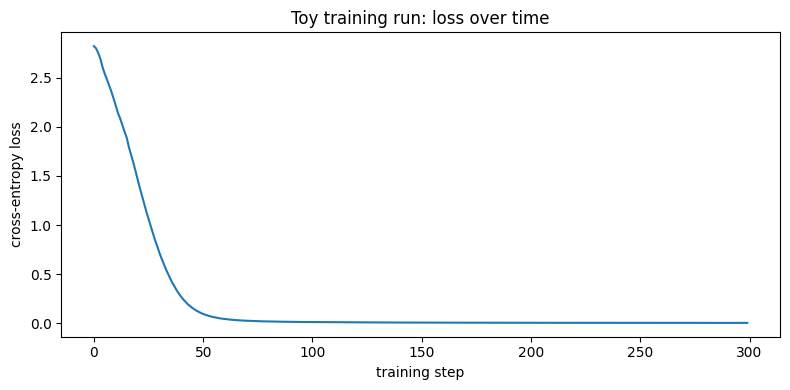

loss at step 0:            2.8193
expected random-init loss: 2.7726  (close now, thanks to GPT-2-style init above)
loss at final step:        0.0047
loss dropped by:           2.8147

PASS: loss dropped substantially -- the training loop is mechanically correct


In [7]:
plt.figure(figsize=(8, 4))
plt.plot(losses)
plt.xlabel("training step")
plt.ylabel("cross-entropy loss")
plt.title("Toy training run: loss over time")
plt.tight_layout()
plt.show()

expected_random_loss = -math.log(1 / TOY_VOCAB)
print(f"loss at step 0:            {losses[0]:.4f}")
print(f"expected random-init loss: {expected_random_loss:.4f}  (close now, thanks to GPT-2-style init above)")
print(f"loss at final step:        {losses[-1]:.4f}")
print(f"loss dropped by:           {losses[0] - losses[-1]:.4f}")
assert losses[-1] < losses[0] * 0.5, "loss should have dropped substantially on this easy repeating pattern"
print("\nPASS: loss dropped substantially -- the training loop is mechanically correct")

## 6. Sampling from the trained toy model

A quick qualitative check: does the model actually predict the next token in the repeating pattern correctly now?

In [8]:
model.eval()
with torch.no_grad():
    context = torch.tensor([[1, 2, 3, 4, 5, 1, 2, 3]])  # feed part of the pattern
    logits = model(context)
    predicted_next = logits[0, -1].argmax().item()

print("context:        ", context[0].tolist())
print("predicted next token:", predicted_next)
print("expected next token (from the pattern):", 4)
print("(pattern repeats 1,2,3,4,5 -- after ...2,3 the next token should be 4)")

context:         [1, 2, 3, 4, 5, 1, 2, 3]
predicted next token: 4
expected next token (from the pattern): 4
(pattern repeats 1,2,3,4,5 -- after ...2,3 the next token should be 4)


## Takeaway

Every mechanism from the blog post -- cross-entropy loss, AdamW, warmup+cosine LR decay, gradient clipping -- is demonstrated here individually, and then combined into a real training loop that measurably drives loss down on a toy task, with a sanity-checked prediction at the end.

**What this notebook does NOT give you:** TaxGPT's real batch size, step count, loss curve, training time, or hardware. Those come from your actual run on the actual ~10.6M-token GST corpus (Episode 2) -- rerun this loop's structure against your real `TaxGPT` model (Episode 10) and real data loader to get the numbers the blog post is still missing.

**Next: Episode 12 — the bug that zeroed 47% of the model's weights.**